# Lab 4.06 - Bivariate Analysis of Qualitative Data


In [1]:
# Importing the necessary packages
import numpy as np                                  # "Scientific computing"
import scipy.stats as stats                         # Statistical tests

import pandas as pd                                 # Data Frame
from pandas.api.types import CategoricalDtype

import matplotlib.pyplot as plt                     # Basic visualisation
from statsmodels.graphics.mosaicplot import mosaic  # Mosaic diagram
import seaborn as sns                               # Advanced data visualisation

## Exercise 6 - Influence of background music on purchasing behaviour

Market research shows that background music in a supermarket can influence the purchasing behaviour of customers. A study compared three methods: no music, French chansons and Italian hits. In each case, the number of bottles of French, Italian and other wines sold was counted (Ryan, et al., 1998).

The research data can be found in the file data/MuziekWijn.csv.

1. Set up the correct crosstab.
2. Determine the marginal totals.
3. Determine the expected results.
4. Calculate the χ² test statistic.
5. Calculate Cramér's V. What can you conclude from this?

Visualize the data set:

1. Plot a bar chart showing the percentages of types of wine sold when no music was playing.
2. Plot a clustered bar chart of the dataset
3. Plot a bar chart (stacked bar chart) of the dataset

Results of the main calculations (rounded up to 3 decimal places):

* χ² ≈ 18.279
* Cramér's V ≈ 0.194

Read the dataset

In [2]:
music_wine = pd.read_csv('../data/MuziekWijn.csv')

Give the names of both columns. What is wrong?

In [3]:
music_wine.columns

Index(['Muziek', ' Wijn'], dtype='str')

You can change the name of a column 'ab' to the column 'abc' of the dataframe df, using the following command

`df = df.rename(columns={'ab': 'abc'})`

Use this command to change the column name.  
Check afterwards if the result is correct.

In [4]:
music_wine = music_wine.rename(columns={' Wijn': 'Wijn'})

music_wine.columns

Index(['Muziek', 'Wijn'], dtype='str')

1. Set up the correct crosstab.

In [5]:
observed = pd.crosstab(music_wine.Wijn, music_wine.Muziek)

observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,35,43,35
Franse,39,30,30
Italiaanse,1,11,19


2. Determine the marginal totals.

In [6]:
row_sums = observed.sum(axis=1)
col_sums = observed.sum()

n = row_sums.sum()

print(row_sums)
print(col_sums)
print(f'Number of observations: {n}')

Wijn
Andere        113
Franse         99
Italiaanse     31
dtype: int64
Muziek
Franse        75
Geen          84
Italiaanse    84
dtype: int64
Number of observations: 243


3. Determine the expected results.

In [7]:
expected = np.outer(row_sums, col_sums) / n
expected

array([[34.87654321, 39.0617284 , 39.0617284 ],
       [30.55555556, 34.22222222, 34.22222222],
       [ 9.56790123, 10.71604938, 10.71604938]])

4. Calculate the χ² test statistic.

In [9]:
exp_row_sums = np.sum(expected, axis=1)
exp_col_sums = np.sum(expected, axis=0)

print(f'Row totals   : {exp_row_sums}')
print(f'Column totals: {exp_col_sums}')
print(f'Observations : {exp_col_sums.sum()}')

Row totals   : [113.  99.  31.]
Column totals: [75. 84. 84.]
Observations : 243.0


In [10]:
expected - observed

Muziek,Franse,Geen,Italiaanse
Wijn,,,
Andere,-0.123457,-3.938272,4.061728
Franse,-8.444444,4.222222,4.222222
Italiaanse,8.567901,-0.283951,-8.283951


In [11]:
diffs = (expected - observed)**2 / expected
print(diffs)

Muziek        Franse      Geen  Italiaanse
Wijn                                      
Andere      0.000437  0.397063    0.422348
Franse      2.333737  0.520924    0.520924
Italiaanse  7.672417  0.007524    6.403837


In [12]:
chi_squared = diffs.values.sum()
print('χ² ≈ %.3f' %chi_squared)

χ² ≈ 18.279


5. Calculate Cramér's V. What can you conclude from this?

In [8]:
stats.contingency.association(observed, method='cramer')

0.19393696480652944

Plot a bar chart showing the percentages of types of wine sold when no music was playing.

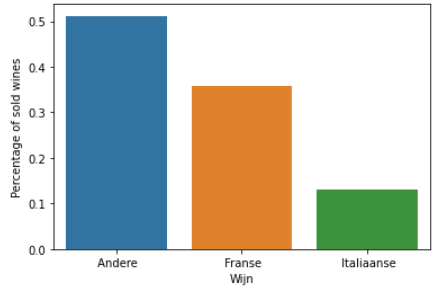

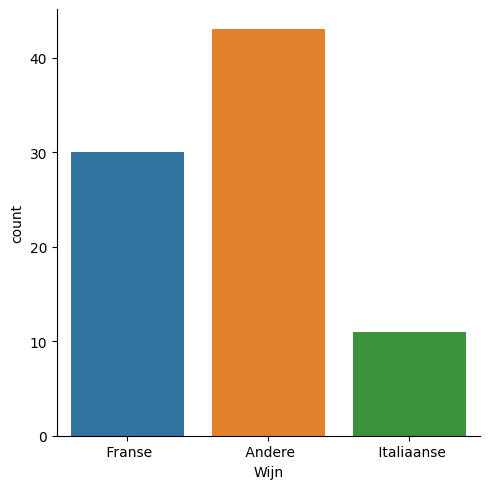

In [13]:
sns.catplot(data=music_wine[
    music_wine.Muziek == 'Geen'
], x='Wijn', hue='Wijn', kind='count')

Plot a clustered bar chart of the dataset  

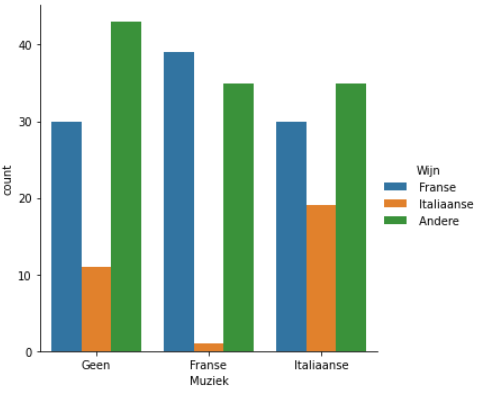

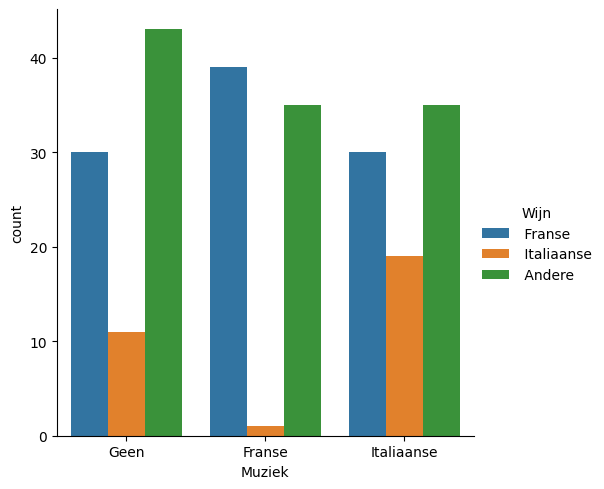

In [15]:
sns.catplot(data=music_wine, x='Muziek', hue='Wijn', kind='count')

Plot a bar chart (stacked bar chart) of the dataset

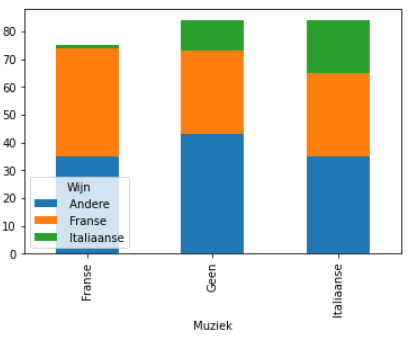

<Axes: xlabel='Muziek'>

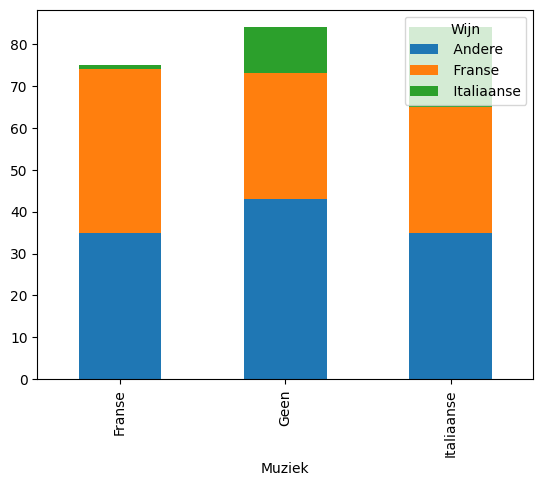

In [16]:
observed.T.plot(kind='bar', stacked=True)